## Setting up libraties, device, and seed

In [34]:
# imports
import numpy as np
import pandas as pd
import torch

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import optuna
import torch.optim as optim


import glob
import os
import contextlib

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

import joblib

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [35]:
%matplotlib inline
# САНЯ я єбу чи то треба, каже що в notebooці воно гарніше виглядатиме, якщо ти щось схоже робив то видали нахуй
# Це тіпа декоратор і фотки зразу під низ вставляє, але я хз
# for images output. In some cases(old version of notebook/ opening file exactly in GitHub) photos output from notebook might be broken. 

In [36]:
#Setting devices for time efficiency
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Using device: {device}")

#Seed to ensure reproducibility
def set_seed(seed=123):
    import random, numpy as np, torch, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(288)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

Using device: cpu


## Data handling

In [37]:
# csv read
df = pd.read_csv('data/AirQualityUCI.csv', sep=";")
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# type casting

df['CO(GT)'] = df['CO(GT)'].str.replace(',', '.').astype(float)
df['C6H6(GT)'] = df['C6H6(GT)'].str.replace(',', '.').astype(float)
df['T'] = df['T'].str.replace(',', '.').astype(float)
df['RH'] = df['RH'].str.replace(',', '.').astype(float)
df['AH'] = df['AH'].str.replace(',', '.').astype(float)

In [39]:
# dropping null values and unrelevant columns
df.drop(inplace=True, columns=['Unnamed: 15', 'Unnamed: 16', "NMHC(GT)"])
df.dropna(inplace=True)

# drop rows where T equals -200
df.drop(df[df['T'] == -200].index, inplace=True)

Avaraging-null-values

In [40]:
df_avaraging_temp=df
#df.info()
# print(df.describe())
print(f"Number of null values in the DataFrame: {np.count_nonzero(df_avaraging_temp == "-200")}")

print(f"Before the avaraging mean of df[CO(GT)]: {df_avaraging_temp['CO(GT)'].mean()}")

pandas_series_null_values_avaraging = (df_avaraging_temp == -200.00).sum()
print(pandas_series_null_values_avaraging)
dictionary_null_values_avaraging = pandas_series_null_values_avaraging.to_dict()

array_keys = dictionary_null_values_avaraging.keys()
to_be_avaraged_column = list()


#i can find better way
for x in array_keys:
    if dictionary_null_values_avaraging[x]>0:
        to_be_avaraged_column.append(x)


lenth_df = len(df_avaraging_temp)
for selected_column in to_be_avaraged_column:
    times_of_200 = np.count_nonzero(df_avaraging_temp[selected_column] == "-200")
    avg_column_value = (df_avaraging_temp[selected_column].sum() +200*times_of_200)/lenth_df
    df_avaraging_temp[selected_column] = df_avaraging_temp[selected_column].replace(-200, avg_column_value) # replace values using string methods



print(f"After the avaraging mean of df[CO(GT)]: {df_avaraging_temp['CO(GT)'].mean()}")

Number of null values in the DataFrame: 0
Before the avaraging mean of df[CO(GT)]: -34.89705260816372
Date                0
Time                0
CO(GT)           1647
PT08.S1(CO)         0
C6H6(GT)            0
PT08.S2(NMHC)       0
NOx(GT)          1595
PT08.S3(NOx)        0
NO2(GT)          1598
PT08.S4(NO2)        0
PT08.S5(O3)         0
T                   0
RH                  0
AH                  0
dtype: int64
After the avaraging mean of df[CO(GT)]: -4.652969152001519


In [41]:
print(df.describe())

# interpolate null values
df.replace(-200, np.nan, inplace=True)

columns_to_interpolate = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
    'PT08.S5(O3)', 'T', 'RH', 'AH'
]

df[columns_to_interpolate] = df[columns_to_interpolate].interpolate(method='linear')

            CO(GT)  PT08.S1(CO)     C6H6(GT)  PT08.S2(NMHC)      NOx(GT)  \
count  8991.000000  8991.000000  8991.000000    8991.000000  8991.000000   
mean     -4.652969  1099.833166    10.083105     939.153376   228.273318   
std      14.382079   217.080037     7.449820     266.831429   189.501782   
min     -34.897053   647.000000     0.100000     383.000000     2.000000   
25%       0.600000   937.000000     4.400000     734.500000   112.000000   
50%       1.500000  1063.000000     8.200000     909.000000   163.745078   
75%       2.600000  1231.000000    14.000000    1116.000000   280.000000   
max      11.900000  2040.000000    63.700000    2214.000000  1479.000000   

       PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)            T  \
count   8991.000000  8991.000000   8991.000000  8991.000000  8991.000000   
mean     835.493605   102.284746   1456.264598  1022.906128    18.317829   
std      256.817320    48.116102    346.206794   398.484288     8.832116   
min      32

Splitting Data

In [42]:
X=df
X=X.drop(columns="Time")
X=X.drop(columns="T")
X=X.drop(columns="Date")
X=X.drop(columns="AH")


y=df["T"]


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=228
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=228
)

In [43]:
y

0       13.6
1       13.3
2       11.9
3       11.0
4       11.2
        ... 
9352    21.9
9353    24.3
9354    26.9
9355    28.3
9356    28.5
Name: T, Length: 8991, dtype: float64

## Exploratory Data Analysis (EDA)

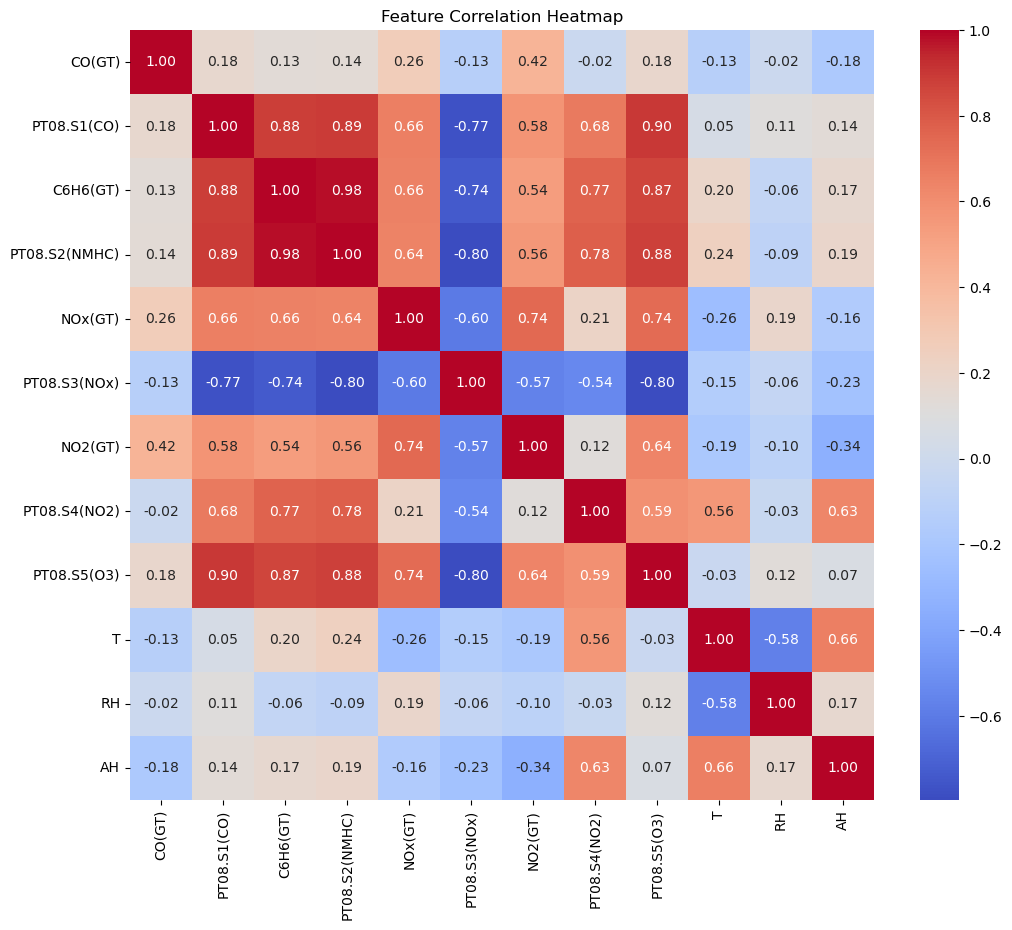

<Figure size 1200x1000 with 0 Axes>

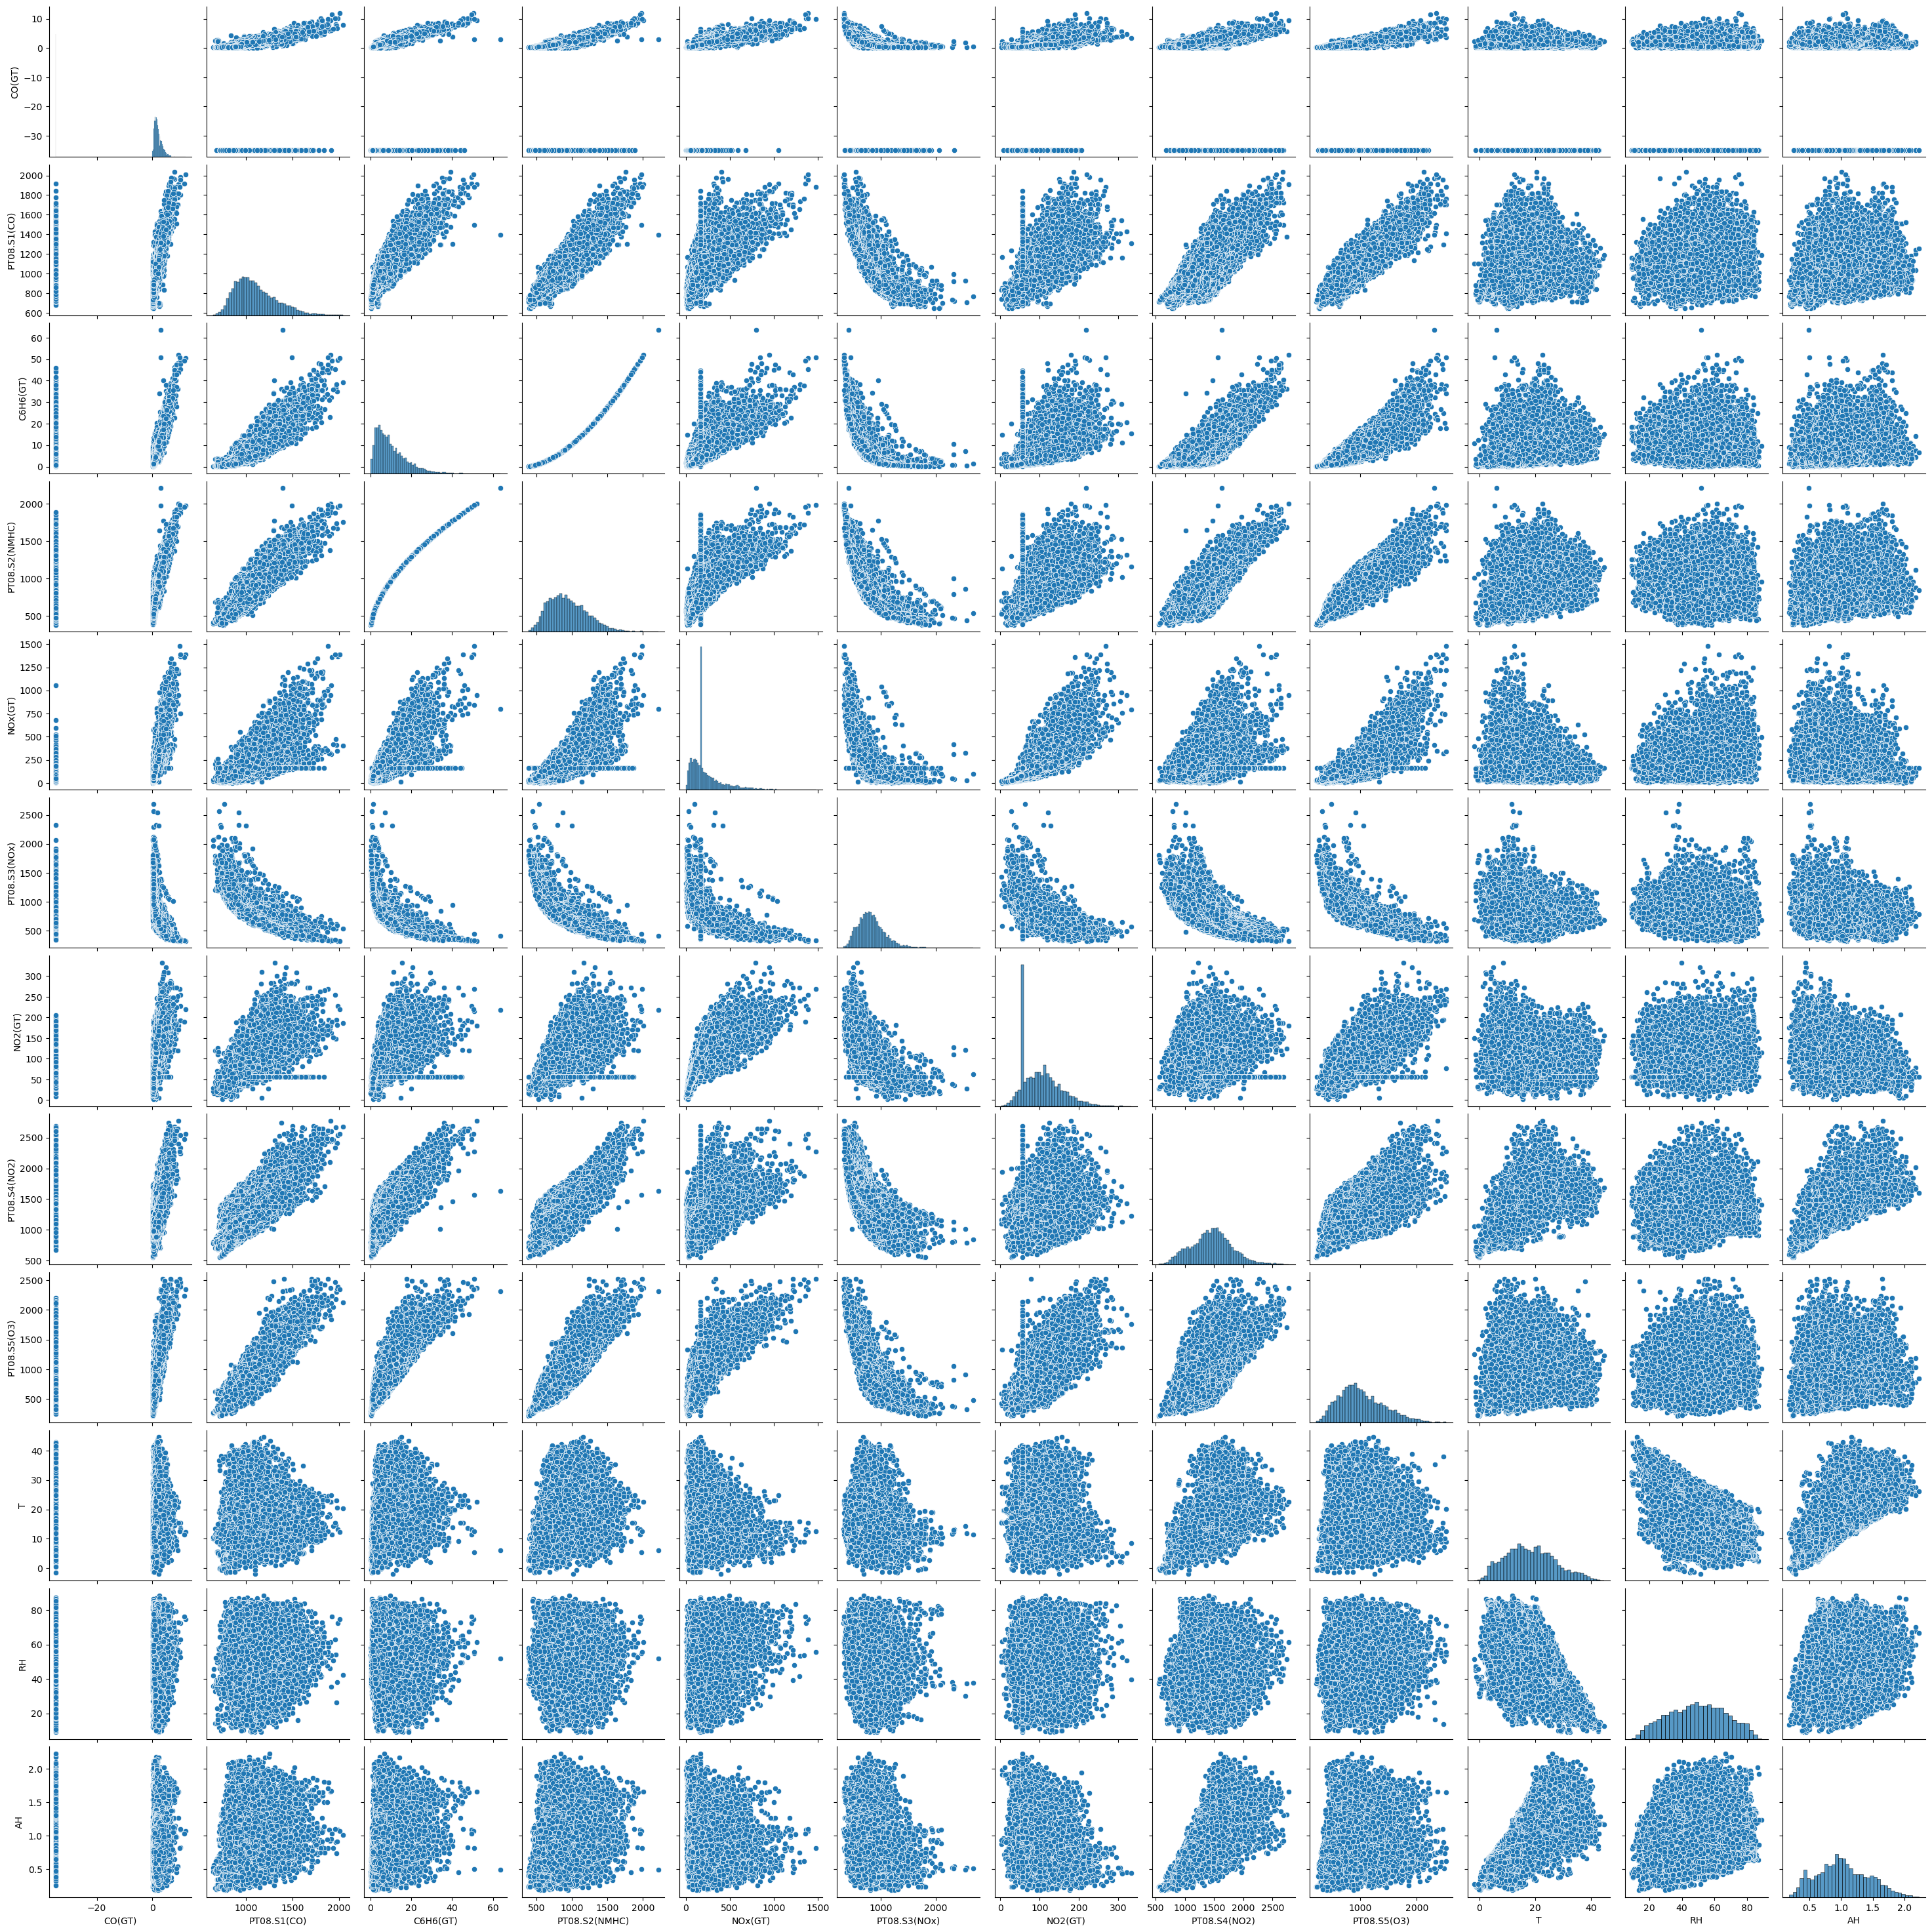

In [44]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

cols_to_check = ['T', 'CO(GT)', 'NOx(GT)', 'C6H6(GT)']
plt.figure(figsize=(12, 10))
sns.pairplot(df)
plt.show()

In [45]:
y = df['T']

X = df.drop(columns=['T', 'Date', 'Time', 'Datetime'], errors='ignore')
X = sm.add_constant(X)
linear_regression_model = sm.OLS(y, X).fit()
print(linear_regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      T   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 1.103e+04
Date:                Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:23:35   Log-Likelihood:                -20318.
No. Observations:                8991   AIC:                         4.066e+04
Df Residuals:                    8979   BIC:                         4.075e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.5153      0.613     13.894

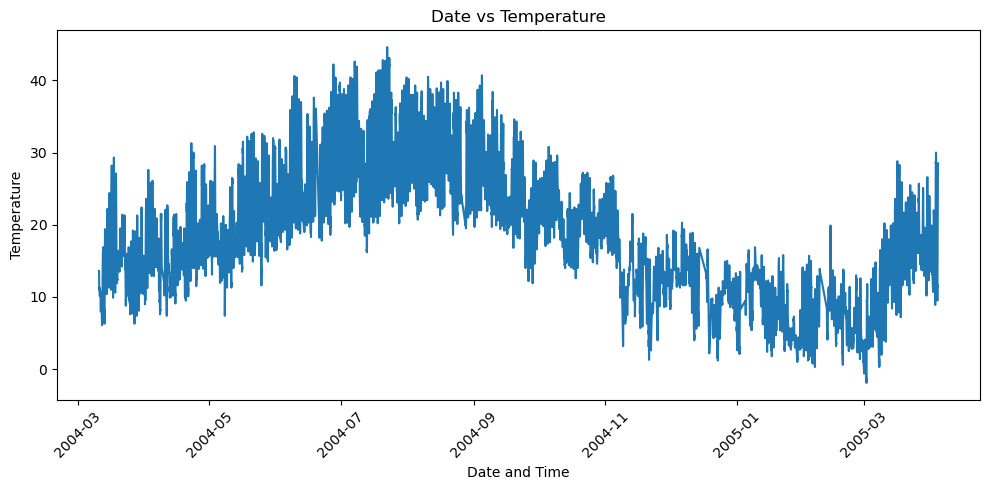

In [46]:
# temperature to datetime visualization
x = df['Date']
y= df['T']

df['Time'] = df['Time'].str.replace('.', ':')
df['Datetime'] = df['Date'] + ' ' + df['Time']
df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True)

plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['T'])
plt.title('Date vs Temperature')
plt.xlabel('Date and Time')
plt.ylabel('Temperature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df.drop(columns=['Datetime'], inplace=True)

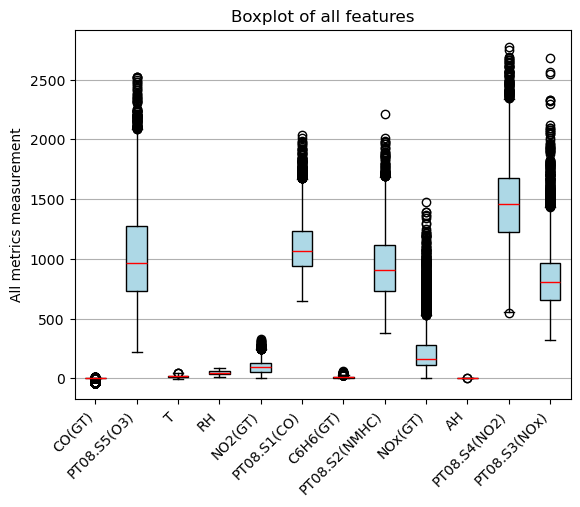

In [47]:
# Histogram for understanding necessity of normalization, test for outliers

features_histogram = list(set(df.columns.tolist()) - set(["Date", "Time"]))

fig, ax = plt.subplots()
ax.boxplot(df[features_histogram], medianprops=dict(color="r"),patch_artist=True,  boxprops={'facecolor': '#ADD8E6'},labels=features_histogram)
# ax.violinplot(df[features_histogram])

ax.grid(axis='y')
plt.xticks(rotation=45, ha="right")
ax.set_title("Boxplot of all features")
ax.set_ylabel("All metrics measurement")


plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_54784\3233121270.py:12: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



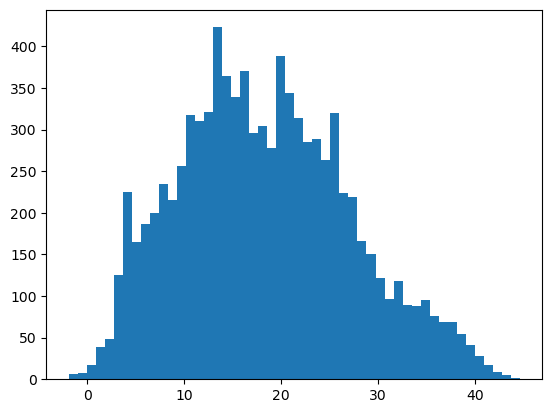

In [48]:
#Temperature distribution

import plotly.figure_factory as ff

fig, ax = plt.subplots()
x1=df["T"]


ax.hist(x1,
    bins=50,
)
fig.show()



## Implementing different ML algorithms

Creating pathes (can split it to model training for better readibility)

In [49]:
weight_path = os.path.join("assets", "weights")
os.makedirs(weight_path, exist_ok=True)

gradient_weight_path = os.path.join(weight_path, "gradientboostweights.joblib")
linear_r_weight_path = os.path.join(weight_path, "linearregression.pth")
deepml_weight_path = os.path.join(weight_path, "deepml.pth")
optima_deepml_weight_path = os.path.join(weight_path, "optimadeepml.pth")



In [50]:
X_train

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH
2890,0.4,876.0,2.3,605.0,29.0,1144.0,40.0,1432.0,456.0,42.2
5801,0.7,805.0,2.7,632.0,115.0,1176.0,63.0,1033.0,475.0,34.7
6095,7.5,1553.0,24.4,1414.0,760.0,455.0,193.0,1851.0,1682.0,56.6
7870,3.2,1377.0,14.4,1129.0,497.0,540.0,162.0,1392.0,1626.0,44.8
8038,1.5,942.0,4.4,733.0,271.0,912.0,156.0,800.0,609.0,20.0
...,...,...,...,...,...,...,...,...,...,...
9338,2.5,1180.0,7.9,894.0,355.0,636.0,187.0,1200.0,1372.0,40.7
2348,2.2,1090.0,14.1,1119.0,117.0,756.0,107.0,1811.0,902.0,25.7
5514,4.4,1477.0,26.7,1471.0,624.0,455.0,146.0,2031.0,1750.0,54.5
1923,1.0,901.0,6.5,834.0,102.0,1177.0,103.0,1408.0,738.0,35.0


## GradientBoost

In [51]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 500],
    'max_depth': [3, 5, None],
    'l2_regularization': [0.0, 0.1, 1.0]
}

base_model = HistGradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Optimal Parameters: {grid_search.best_params_}")

best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

print(f"Optimal MSE: {mean_squared_error(y_test, predictions):.2f}")
print(f"Optimal R2: {r2_score(y_test, predictions):.2f}")

gradient_model = best_model

Optimal Parameters: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': None, 'max_iter': 500}
Optimal MSE: 2.57
Optimal R2: 0.96


# Linear regression

In [52]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        # nn.Linear automatically manages weights and biases
        self.linear = nn.Linear(input_dim, output_dim) 
        
    def forward(self, x):
        return self.linear(x)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 1. Scale the raw Pandas features FIRST
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

linear_regression_model = LinearRegressionModel(input_dim=X_train_tensor.shape[1], output_dim=1)
criterion = nn.MSELoss() 
optimizer = optim.Adam(linear_regression_model.parameters(), lr=0.01)

epochs = 30000
for epoch in range(epochs):
    # Forward Pass: Compute predictions
    predictions = linear_regression_model(X_train_tensor)
    # Compute Loss using the new tensor
    loss = criterion(predictions, y_train_tensor)
    
    # Backward Pass: Clear past gradients, calculate new ones, and update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print progress every 100 epochs
    if (epoch + 1) % 2000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


linear_regression_model.eval()

with torch.no_grad():
    test_predictions = linear_regression_model (X_test_tensor)

    y_pred_np=test_predictions.cpu().numpy()

y_test_np = y_test.values

regression_mse = mean_squared_error(y_test_np, y_pred_np)
regression_r2 = r2_score(y_test_np, y_pred_np)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(f"Mean Squared Error (MSE): {regression_mse:.4f}")
print(f"R-Squared (R2 Score):     {regression_r2:.4f}")


Epoch [2000/30000], Loss: 21.7367
Epoch [4000/30000], Loss: 5.6017
Epoch [6000/30000], Loss: 5.0625
Epoch [8000/30000], Loss: 4.8430
Epoch [10000/30000], Loss: 4.7118
Epoch [12000/30000], Loss: 4.6483
Epoch [14000/30000], Loss: 4.6169
Epoch [16000/30000], Loss: 4.5976
Epoch [18000/30000], Loss: 4.5838
Epoch [20000/30000], Loss: 4.5729
Epoch [22000/30000], Loss: 4.5640
Epoch [24000/30000], Loss: 4.5565
Epoch [26000/30000], Loss: 4.5501
Epoch [28000/30000], Loss: 4.5445
Epoch [30000/30000], Loss: 4.5398

--- FINAL TEST SET PERFORMANCE ---
Mean Squared Error (MSE): 4.3390
R-Squared (R2 Score):     0.9406


# DeepML

In [53]:
import copy
from sklearn.metrics import mean_squared_error, r2_score

class AirQualityMLP(nn.Module):
    def __init__(self, input_dim, h1, h2):
        super(AirQualityMLP, self).__init__()

        self.layer1 = nn.Linear(input_dim, h1)

        self.layer2 = nn.Linear(h1, h2) 

        self.outputlayer = nn.Linear(h2, 1)

            
    def forward(self, x):
        x = F.relu(self.layer1(x))

        x = F.relu(self.layer2(x))

        x = self.outputlayer(x)

        return x


# 1. Scale the raw Pandas features FIRST
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Math magic happens here
X_test_scaled = scaler.transform(X_test)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

# Scale the validation data using the existing scaler
X_val_scaled = scaler.transform(X_val) 

# Convert to tensors and send to GPU/MPS
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        """
        patience (int): How many epochs to wait after last time validation loss improved.
        min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf 
        self.early_stop = False

        self.best_weights = None


    def __call__(self, val_loss, model):
        # If this is the first epoch, set the baseline
        if self.best_loss == np.inf:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        
        # If the loss went up (got worse) or didn't improve enough
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter == 2 or self.counter == 5 or self.counter == 15 or self.counter == 20 or self.counter == 45 or self.counter == 60:
                print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            # Trigger the stop flag if patience is exceeded
            if self.counter >= self.patience:
                self.early_stop = True
                
        # If the loss went down
        else:
            is_significant = (val_loss < (self.best_loss * 0.90)) or (val_loss < 3.5)

            self.save_checkpoint(val_loss, model, is_significant=is_significant)

            self.best_loss = val_loss
            self.counter = 0 # Reset the counter

    def save_checkpoint(self, val_loss, model, is_significant=True):
        """Saves the best model weights into memory."""
        if is_significant:
            print(f'   -> Validation loss decreased to {val_loss:.4f}. Saving weights to memory...')
        # We use deepcopy so it takes a real snapshot, not just a reference
        self.best_weights = copy.deepcopy(model.state_dict())


1 Version with manually done random hyperparamters

In [54]:
deepml_model = AirQualityMLP(input_dim=X_train_tensor.shape[1], h1=64, h2=32)

criterion = nn.MSELoss() 
optimizer = optim.AdamW(deepml_model.parameters(), lr=0.001, weight_decay=1e-4) # Adam is highly reliable

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

early_stopping = EarlyStopping(patience=15, min_delta=0.001) # Increased patience to allow for restarts


epochs = 30
for epoch in range(epochs):
    deepml_model.train()
    running_train_loss = 0.0
    # Forward Pass: Compute predictions
    for batch_X, batch_y in train_loader:
        noise = torch.randn_like(batch_X) * 0.01
        
        noisy_batch_X = batch_X + noise
        predictions = deepml_model(noisy_batch_X)
        # Compute Loss using the new tensor
        
        loss = criterion(predictions, batch_y)
        
        # Backward Pass: Clear past gradients, calculate new ones, and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    
    with torch.no_grad(): 
        # Pass the entire validation tensor at once (No val_loader needed)
        val_preds = deepml_model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor)
        
        # Define avg_val_loss for EarlyStopping
        avg_val_loss = val_loss.item() 
        
        # Calculate R2 for the progress printout
        r2_val = r2_score(y_val_tensor.cpu().numpy(), val_preds.cpu().numpy())
    
    """# Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f} | Val R2: {r2_val:.4f}")

    But since 
        """
    # ==========================
    #  EARLY STOPPING CHECK
    # ==========================
    early_stopping(avg_val_loss, deepml_model)
    
    if early_stopping.early_stop:
        print("Early stopping triggered! Training stopped to prevent overfitting.")
        break

"""X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)"""

deepml_model.load_state_dict(early_stopping.best_weights)
deepml_model.eval()

# 2. Make predictions on the Test Set
with torch.no_grad():
    # Pass the test tensor into the model
    test_predictions = deepml_model(X_test_tensor)
    
    # 3. Convert both the predictions and actuals to NumPy arrays
    y_pred_np = test_predictions.cpu().numpy()
    y_test_np = y_test_tensor.cpu().numpy()


mse = mean_squared_error(y_test_np, y_pred_np)
r2 = r2_score(y_test_np, y_pred_np)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-Squared (R2 Score):     {r2:.4f}")


   -> Validation loss decreased to 25.8240. Saving weights to memory...
   -> Validation loss decreased to 11.5712. Saving weights to memory...
   -> Validation loss decreased to 8.5052. Saving weights to memory...
   -> Validation loss decreased to 6.7488. Saving weights to memory...
   -> Validation loss decreased to 5.6816. Saving weights to memory...
   -> Validation loss decreased to 5.0263. Saving weights to memory...
   -> Validation loss decreased to 4.5146. Saving weights to memory...
   -> Validation loss decreased to 3.4142. Saving weights to memory...
   -> Validation loss decreased to 3.3498. Saving weights to memory...
   -> Validation loss decreased to 3.2704. Saving weights to memory...
   -> Validation loss decreased to 3.1425. Saving weights to memory...
   -> Validation loss decreased to 3.0997. Saving weights to memory...
   -> Validation loss decreased to 2.9315. Saving weights to memory...
   -> Validation loss decreased to 2.9149. Saving weights to memory...
   -

In [61]:
def objective(trial):
    # 1. Suggest architectural, optimizer, and noise hyperparameters


    #parametres
    h1 = trial.suggest_int("units_layer1", 16, 128, log=True)
    h2 = trial.suggest_int("units_layer2", 16, 128, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    deepml_model =  AirQualityMLP(input_dim=X_train_tensor.shape[1], h1=h1, h2=h2)

    total_params = sum(p.numel() for p in deepml_model.parameters() if p.requires_grad)

    # Setup Optimizer
    opt = getattr(optim, optimizer_name)(deepml_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # 4. Create the proper DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    early_stopping = EarlyStopping(patience=40, min_delta=0.001)

    #Normal epochs
    #epoch = 2500
    #Fast epochs
    epoch = 100

    for epoch in range(epoch):
        deepml_model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            outputs = deepml_model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            opt.step()
            
        deepml_model.eval()
        with torch.no_grad():
            val_preds = deepml_model(X_val_tensor.to(device))
            val_loss = criterion(val_preds, y_val_tensor.to(device)).item()

        early_stopping(val_loss, deepml_model)
            
        if early_stopping.early_stop:
            print()
            break
            # Break out of the 100-epoch loop and move to the next Optuna trial
            

    # 6. Return the best Validation MSE found by Early Stopping
    return early_stopping.best_loss, total_params

if __name__ == "__main__":
    # 3. Create a study with specific directions for each objective index
    study = optuna.create_study(directions=["minimize", "minimize"])    
    # Run optimization

    # Silent training process so it would not be so messy
    with open(os.devnull, 'w') as null_file:
        with contextlib.redirect_stdout(null_file):
            study.optimize(objective, n_trials=20)

    # 4. View results on the Pareto Front
    print(f"\nNumber of Pareto-optimal trials: {len(study.best_trials)}")
    for t in study.best_trials:
        # Updated print statement to reflect MSE instead of Accuracy
        print(f"Trial #{t.number} -> Val MSE: {t.values[0]:.4f}, Params: {t.values[1]} | Params: {t.params}")


[I 2026-08-18 17:37:10,138] A new study created in memory with name: no-name-674281b4-a50e-4851-833a-6c58a79cc1ad


[I 2026-08-18 17:37:50,199] Trial 0 finished with values: [1.732016682624817, 1233.0] and parameters: {'units_layer1': 36, 'units_layer2': 22, 'optimizer': 'Adam', 'lr': 0.004153975814691179, 'batch_size': 32}.
[I 2026-08-18 17:39:01,009] Trial 1 finished with values: [1.8838229179382324, 2352.0] and parameters: {'units_layer1': 19, 'units_layer2': 102, 'optimizer': 'RMSprop', 'lr': 0.0011047323288255035, 'batch_size': 16}.
[I 2026-08-18 17:39:42,728] Trial 2 finished with values: [1.7304627895355225, 3411.0] and parameters: {'units_layer1': 50, 'units_layer2': 55, 'optimizer': 'RMSprop', 'lr': 0.004869364355165628, 'batch_size': 32}.
[I 2026-08-18 17:40:07,387] Trial 3 finished with values: [3.23793363571167, 8491.0] and parameters: {'units_layer1': 74, 'units_layer2': 101, 'optimizer': 'RMSprop', 'lr': 0.00011021038645338647, 'batch_size': 64}.
[I 2026-08-18 17:40:46,986] Trial 4 finished with values: [1.6927714347839355, 3073.0] and parameters: {'units_layer1': 89, 'units_layer2': 2


Number of Pareto-optimal trials: 6
Trial #0 -> Val MSE: 1.7320, Params: 1233.0 | Params: {'units_layer1': 36, 'units_layer2': 22, 'optimizer': 'Adam', 'lr': 0.004153975814691179, 'batch_size': 32}
Trial #4 -> Val MSE: 1.6928, Params: 3073.0 | Params: {'units_layer1': 89, 'units_layer2': 23, 'optimizer': 'RMSprop', 'lr': 0.006137275417779239, 'batch_size': 32}
Trial #7 -> Val MSE: 1.6398, Params: 4653.0 | Params: {'units_layer1': 36, 'units_layer2': 112, 'optimizer': 'RMSprop', 'lr': 0.0011266008162245972, 'batch_size': 32}
Trial #9 -> Val MSE: 1.7290, Params: 1554.0 | Params: {'units_layer1': 19, 'units_layer2': 64, 'optimizer': 'RMSprop', 'lr': 0.007556780130680428, 'batch_size': 64}
Trial #11 -> Val MSE: 1.7100, Params: 2324.0 | Params: {'units_layer1': 33, 'units_layer2': 56, 'optimizer': 'RMSprop', 'lr': 0.004768086889696798, 'batch_size': 32}
Trial #17 -> Val MSE: 1.9307, Params: 879.0 | Params: {'units_layer1': 23, 'units_layer2': 25, 'optimizer': 'RMSprop', 'lr': 0.001523568726

# Implementing best model parameters

In [62]:
#Trial #2 -> Val MSE: 1.3073, Params: 10979.0 | Params: {'units_layer1': 98, 'units_layer2': 99, 'optimizer': 'Adam', 'lr': 0.0010040790335494043, 'batch_size': 32}
pareto_trials = study.best_trials
pareto_trials.sort(key=lambda t: t.values[0])
best_trial = pareto_trials[0]

print(best_trial.params)

best_h1 = best_trial.params["units_layer1"]
best_h2 = best_trial.params["units_layer2"]
best_lr = best_trial.params["lr"]
best_optimizer_name = best_trial.params["optimizer"]
best_batch_size = best_trial.params["batch_size"]




final_deepml_model = AirQualityMLP(input_dim=X_train_tensor.shape[1], h1=best_h1, h2=best_h2)

criterion = nn.MSELoss() 
final_optimizer = getattr(optim, best_optimizer_name)(final_deepml_model.parameters(), lr=best_lr)

final_dataset = TensorDataset(X_train_tensor, y_train_tensor)
final_loader = DataLoader(final_dataset, batch_size=best_batch_size, shuffle=True)

final_early_stopping = EarlyStopping(patience=100, min_delta=0.001)
epochs = 5000

for epoch in range(epochs):
    deepml_model.train()
    running_train_loss = 0.0
    # Forward Pass: Compute predictions
    for batch_X, batch_y in final_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        final_optimizer.zero_grad()

        noise = torch.randn_like(batch_X) * 0.01
        noisy_batch_X = batch_X + noise

        outputs = final_deepml_model(noisy_batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        final_optimizer.step()
        # Compute Loss using the new tensor
        
        
        # Backward Pass: Clear past gradients, calculate new ones, and update weights
    final_deepml_model.eval()
    with torch.no_grad():
        val_preds = final_deepml_model(X_val_tensor.to(device))
        val_loss = criterion(val_preds, y_val_tensor.to(device)).item()

    final_early_stopping(val_loss, final_deepml_model)
    if final_early_stopping.early_stop:
        print(f"Final training stopped early at epoch {epoch+1}.")
        break

# ==========================
# FINAL TEST SET PERFORMANCE
# ==========================
print("\n--- FINAL TEST SET PERFORMANCE ---")

# Load the absolute best weights from memory
final_deepml_model.load_state_dict(final_early_stopping.best_weights)
final_deepml_model.eval()

with torch.no_grad():
    test_predictions = final_deepml_model(X_test_tensor.to(device))
    
    y_pred_np = test_predictions.cpu().numpy()
    y_test_np = y_test_tensor.cpu().numpy()

# Calculate final metrics
final_mse = mean_squared_error(y_test_np, y_pred_np)
final_r2 = r2_score(y_test_np, y_pred_np)

print(f"Mean Squared Error (MSE): {final_mse:.4f}")
print(f"R-Squared (R2 Score):     {final_r2:.4f}")


{'units_layer1': 36, 'units_layer2': 112, 'optimizer': 'RMSprop', 'lr': 0.0011266008162245972, 'batch_size': 32}
   -> Validation loss decreased to 10.9202. Saving weights to memory...
   -> Validation loss decreased to 6.5758. Saving weights to memory...
   -> Validation loss decreased to 5.0684. Saving weights to memory...
   -> Validation loss decreased to 4.3583. Saving weights to memory...
   -> EarlyStopping counter: 2 out of 100
   -> Validation loss decreased to 3.6661. Saving weights to memory...
   -> Validation loss decreased to 3.2584. Saving weights to memory...
   -> EarlyStopping counter: 2 out of 100
   -> Validation loss decreased to 3.1386. Saving weights to memory...
   -> Validation loss decreased to 3.1120. Saving weights to memory...
   -> Validation loss decreased to 3.1096. Saving weights to memory...
   -> Validation loss decreased to 3.1065. Saving weights to memory...
   -> Validation loss decreased to 3.0957. Saving weights to memory...
   -> Validation loss

In [63]:
joblib.dump(gradient_model, gradient_weight_path)

torch.save(linear_regression_model, linear_r_weight_path)
torch.save(deepml_model, deepml_weight_path)
#torch.save(final_deepml_model, optima_deepml_weight_path)



joblib.dump(scaler, os.path.join(weight_path, "scaler.joblib"))
joblib.dump(poly, os.path.join(weight_path, "poly.joblib"))

# 1. Scaler for raw 10 features (DeepML)
scaler_raw = StandardScaler()
X_train_scaled = scaler_raw.fit_transform(X_train)
joblib.dump(scaler_raw, os.path.join(weight_path, "scaler_raw.joblib"))

# 2. Polynomial expansion + Scaler for 65 features (Linear Regression)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)

joblib.dump(poly, os.path.join(weight_path, "poly.joblib"))
joblib.dump(scaler_poly, os.path.join(weight_path, "scaler_poly.joblib"))

['assets\\weights\\scaler_poly.joblib']